## Notes for Task 2:
- cv.findContours(image: cv.Mat, mode: int, method: int) -> np.ndarray
● Returns an array of contours found in the image. Each contour consists of an array of
points that define the boundary of the contour.
● Pass a binary image as the image argument.
● The mode argument specifies the format of the returned contour list. For now, use
cv.RETR_TREE for mode. Other modes can be found here:
https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga819779b9857cc2f8
601e6526a3a5bc71
● Mode determines how the contours will be retrieved from the image. Passing
cv.CHAIN_APPROX_NONE causes every point in a contour to be returned while
cv.CHAIN_APPROX_SIMPLE only returns the critical points in a contour, such as the
contour corners, saving space. A representation of this can be seen below


cv.contourArea(contour) -> int
● Returns the area (in pix sq.) of a contour.
● cv.findContours() returns a list of contours of all contours detected in an image. Do not
pass this list as the argument for cv.contourArea(), pass only one of the contours
contained in the list at a time.
● This function is useful to filter out small contours that can result from noise. See the
function below.
def filter_contours(min_

cv.boundingRect(contour) -> tuple
● Returns the (x,y) coordinate of the top left corner and width and height of a bounding box
that surrounds a contour.
● Like cv.contourArea(), this function only takes a single contour as an argument.
● Use cv.rectangle() to draw the bounding box.

cv.moments(contour)
● Returns a dictionary containing all the moment values of the pixels in a contour, about its
centre of mass.
● Can be useful to locate the centre of mass of a contour. All pixels carry the same weight
so the centre of mass is effectively the average coordinate of all the pixels contained in a
contour.
● To draw the centre of mass of a contour, use the following code:

## Task 2: Drawing a bounding box
In this task, our goal is to use contours to locate the position of a ball and draw a bounding box
around it as in the image below.
Original
1. Create a new python file and download the original image of the blue ball.
2. In your program, read the image and create a grayscale copy.
3. Find the edges of the ball using Canny edge detector. Make sure to use the provided
function to obtain the min and max canny threshold values.
4. Pass the canny image into cv.findContours() to get a list of contours in the image. You
may wish to filter these contours for area, however, as the image contains very little
noise as is, this step is not required.
5. Using a for loop, draw the bounding rectangle of the contours onto the original image.
Find the coordinates of the bounding rectangle using cv.boundingRect(). If you’ve
forgotten how to use cv.rectangle() you can find an explanation in lesson 2 or in the
OpenCV docs.
6. Display your result using cv.imshow().

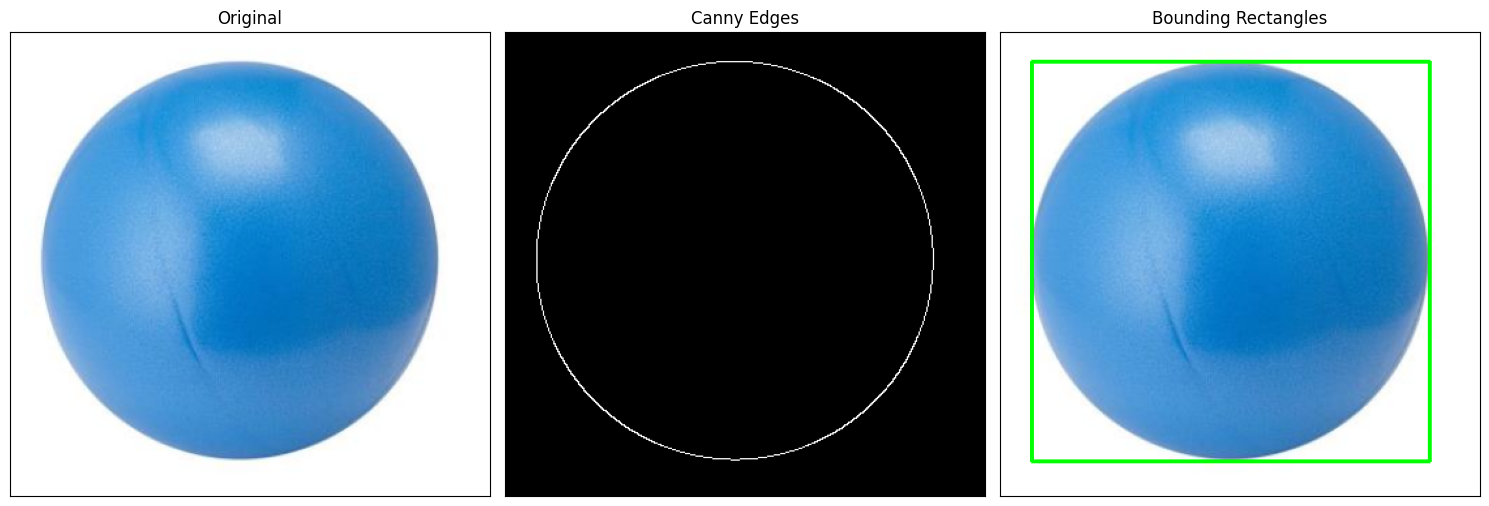

Contours found: 1


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def canny_threshold_values(img, deviation=0.33):
    """Calculate reasonable Canny threshold values using median intensity."""
    avgIntense = np.median(img)
    minVal = avgIntense * (1 - deviation)
    maxVal = avgIntense * (1 + deviation)
    return minVal, maxVal

# Read the ball image
img = cv.imread("FASTR_Ball.png")

# Create a grayscale copy for edge detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise before Canny
blurred = cv.GaussianBlur(gray, (5, 5), 0)

# Get Canny threshold values from the blurred image
minVal, maxVal = canny_threshold_values(blurred)

# Apply Canny edge detection to find edges
edges = cv.Canny(blurred, minVal, maxVal)

# Find contours from the Canny edge image
# RETR_EXTERNAL — only finds outer contours (ignores nested ones)
# CHAIN_APPROX_SIMPLE — compresses contour points to save memory
contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Make a copy of the original to draw on (so we don't modify the original)
result = img.copy()

# Loop through each contour and draw its bounding rectangle
for contour in contours:
    # boundingRect returns the top-left corner (x, y), width and height of the rectangle
    x, y, w, h = cv.boundingRect(contour)

    # Draw a green rectangle on the image
    # pt1 = top-left corner, pt2 = bottom-right corner (x+w, y+h)
    cv.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display original, edges, and result with bounding rectangles
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title("Bounding Rectangles")
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

# Print how many contours were found
print(f"Contours found: {len(contours)}")